In [34]:
import sys
from pathlib import Path

# Ajustar el path del proyecto para importar el módulo desde src/
project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if not (project_root / "src").exists():
    raise FileNotFoundError("No se encontró la carpeta 'src' en el árbol de directorios.")

# Importante: insertar la raíz del proyecto, no la carpeta src.
sys.path.insert(0, str(project_root.resolve()))
print("project_root:", project_root)
print("sys.path[0]:", sys.path[0])

project_root: c:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project
sys.path[0]: C:\Users\nicob\One Drive Uniandes\OneDrive - Universidad de los Andes\Doctorado\proyecto\clusterization_project


In [35]:
import pandas as pd
import inspect
pd.set_option('display.max_columns', None)
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import seaborn as sns
from src import open_cluster_pipeline as ocp

In [50]:
config = ocp.ClusterSimulationConfig(
    n_members=455,

    center_l_deg=221.0,
    center_b_deg=84.0,

    distance_pc=85.0,
    radius_pc=5.0,

    apex_ra_deg=94.7,
    apex_dec_deg=8.2,

    speed_kms=49.0,
    velocity_dispersion_1d_kms=0.4,

    parallax_error_mas=0.02,
    radial_velocity_error_kms=1.0,

    pmra_error_distribution="log10_triangular",
    pm_error_slope=0.7,
    pmra_pmdec_corr=0.2,

    seed=42,
    include_true_values=True,
)


catalog = ocp.simulate_cluster(
    config,
    add_noise=True,
)

print(catalog.head())

ocp.save_catalog(
    catalog,
    "results/catalogo_simulado.csv",
)

   source_id          ra        dec   parallax        pmra      pmdec  \
0          1  188.253670  27.386544  11.681284 -120.080222  19.315599   
1          2  189.289937  24.947091  12.058523 -122.935031  18.575819   
2          3  187.895167  26.238272  11.830651 -122.139571  19.549172   
3          4  183.930677  26.894309  11.322183 -116.308722  14.602732   
4          5  183.167246  27.330743  11.743835 -119.021350  14.637249   

   radial_velocity  distance_pc_true  radial_velocity_true  x_pc_true  \
0         0.779907         85.462598              0.845736 -75.098250   
1        -1.648639         82.723357             -1.084765 -74.021314   
2        -0.231782         84.424575              0.445516 -75.007942   
3         4.623158         88.410414              4.194410 -78.662689   
4         4.861223         85.251250              3.783745 -75.619055   

   y_pc_true  z_pc_true  vx_kms_true  vy_kms_true  vz_kms_true  \
0 -10.893640  39.312049    -4.158789    48.601693     7.

WindowsPath('results/catalogo_simulado.csv')

In [51]:
catalog = pd.read_csv(
    "results/catalogo_simulado.csv"
)

reconstructed = ocp.reconstruct_icrs_velocities(
    catalog
)

print(
    reconstructed[
        [
            "source_id",
            "vx_kms",
            "vy_kms",
            "vz_kms",
            "speed_kms",
        ]
    ].head()
)

ocp.save_catalog(
    reconstructed,
    "results/velocidades_reconstruidas.csv",
)

   source_id    vx_kms     vy_kms    vz_kms  speed_kms
0          1 -4.112560  48.644125  7.318835  49.363239
1          2 -3.286790  48.433113  5.925851  48.904858
2          3 -3.086313  48.980932  6.923652  49.564040
3          4 -4.692455  48.489543  7.543991  49.296721
4          5 -4.257857  47.881576  7.480779  48.649118


WindowsPath('results/velocidades_reconstruidas.csv')

In [52]:
reconstructed, apex = ocp.analyze_catalog_apex(
    catalog,
    true_apex_ra_deg=94.7,
    true_apex_dec_deg=8.2,
    method="mean",
)

print("RA del ápex:", apex["apex_ra_deg"])
print("Dec del ápex:", apex["apex_dec_deg"])
print("l del ápex:", apex["apex_l_deg"])
print("b del ápex:", apex["apex_b_deg"])
print("Error angular:", apex["apex_error_deg"])

RA del ápex: 94.71729013780565
Dec del ápex: 8.212000253733867
l del ápex: 201.89848289998739
b del ápex: -3.418327308155848
Error angular: 0.020901305952171476


In [53]:
velocities = reconstructed[
    ["vx_kms", "vy_kms", "vz_kms"]
].to_numpy()

apex_result = ocp.estimate_apex_from_velocities(
    velocities,
    method="median",
)

print(apex_result)

{'apex_ra_deg': 94.69393937239104, 'apex_dec_deg': 8.209429335938552, 'apex_l_deg': 201.88987000141853, 'apex_b_deg': -3.439933562812937, 'vx_mean_kms': -3.971551883744447, 'vy_mean_kms': 48.36957381276329, 'vz_mean_kms': 7.001771482267356, 'speed_kms': 49.03482129144067, 'stellar_speed_mean_kms': 49.018520534644104, 'stellar_speed_std_kms': 0.42192285145432257, 'velocity_residual_rms_kms': 0.7053483106363555, 'n_sources_used': 455}


In [54]:
pole_metrics = ocp.calculate_pole_apex_metrics(
    ra_deg=reconstructed["ra"].to_numpy(),
    dec_deg=reconstructed["dec"].to_numpy(),

    velocities_kms=reconstructed[
        ["vx_kms", "vy_kms", "vz_kms"]
    ].to_numpy(),

    # Ápex recuperado con las velocidades.
    apex_ra_deg=apex_result["apex_ra_deg"],
    apex_dec_deg=apex_result["apex_dec_deg"],

    # Ápex inicial de la simulación.
    initial_apex_ra_deg=94.7,
    initial_apex_dec_deg=8.2,
)

In [55]:
signed_initial = pole_metrics[
    "pole_apex_error_direction_signed_initial_deg"
]

rms_pole = pole_metrics[
    "rms_pole_residual_deg"
]
print(rms_pole)

0.4611274945808337


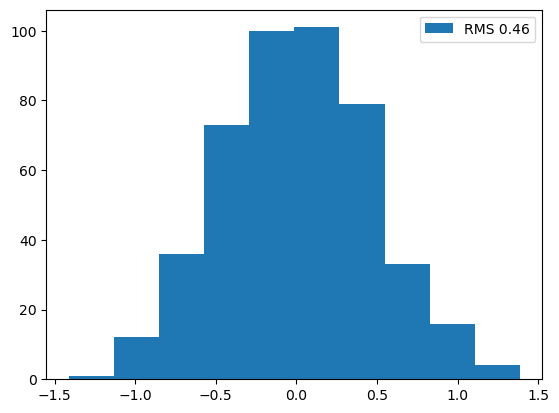

In [56]:
plt.hist(signed_initial, label = f"RMS {np.round(rms_pole,2)}")
plt.legend()